# Sentinel-2 acquisition planner

Short driver notebook for the reusable Sentinel-2 Python module.

Edit only the paths in the configuration cell, then run the notebook top-to-bottom.

In [1]:
%pip install -q requests beautifulsoup4 shapely pandas geopandas pyogrio matplotlib

Note: you may need to restart the kernel to use updated packages.


In [1]:
from pathlib import Path
from datetime import datetime, timedelta, timezone
import importlib.util
import sys

# ------------------------------------------------------------
# EDIT THESE PATHS
# ------------------------------------------------------------

# Your Sentinel-2 Python module.
# Change the filename here if yours is named differently.
MODULE_FILE = Path(
    r"C:\iamo\fire-school\notebooks\sentinel2_acquisition.py"
)

# Your AOI: .shp, .geojson or .json
AOI = Path(
    r"C:\iamo\fire-school\data\aoi\ALB_WF001_AOI.shp"
)

# Local timezone used only for plot titles.
#TIMEZONE = "Europe/Tirane"
TIMEZONE = "UTC" # UTC stands for Coordinated Universal Time, Albania summertime + 2 hours

# Number of days to search.
DAYS = 14

print("Module:", MODULE_FILE)
print("AOI:   ", AOI)
print("Days:  ", DAYS)
print("TZ:    ", TIMEZONE)

Module: C:\iamo\fire-school\notebooks\sentinel2_acquisition.py
AOI:    C:\iamo\fire-school\data\aoi\ALB_WF001_AOI.shp
Days:   14
TZ:     UTC


In [8]:
if not MODULE_FILE.exists():
    raise FileNotFoundError(
        f"Python module not found: {MODULE_FILE}"
    )

module_name = "sentinel2_acquisition_module"

spec = importlib.util.spec_from_file_location(
    module_name,
    MODULE_FILE,
)

s2mod = importlib.util.module_from_spec(spec)

# Important for dataclasses / postponed annotations
sys.modules[module_name] = s2mod

spec.loader.exec_module(s2mod)

find_sentinel2_acquisitions = (
    s2mod.find_sentinel2_acquisitions
)

plot_sentinel2_overpasses = (
    s2mod.plot_sentinel2_overpasses
)

print("Sentinel-2 functions loaded successfully.")

Sentinel-2 functions loaded successfully.


## List planned Sentinel-2 acquisitions for the next week

In [9]:
sentinel2 = find_sentinel2_acquisitions(
    aoi_path=AOI,
    days=DAYS,
)

AOI: C:\iamo\fire-school\data\aoi\ALB_WF001_AOI.shp
Search window: 2026-09-06T19:41:21Z to 2026-09-20T19:41:21Z
Reading S2A plan: 2026-09-03T15:00:00Z → 2026-09-21T18:00:00Z
Reading S2A plan: 2026-08-20T15:00:00Z → 2026-09-07T18:00:00Z
Reading S2B plan: 2026-08-27T12:00:00Z → 2026-09-14T15:00:00Z
Reading S2C plan: 2026-09-03T12:00:00Z → 2026-09-21T15:00:00Z
Reading S2C plan: 2026-08-20T12:00:00Z → 2026-09-07T15:00:00Z
Found 7 acquisition(s).


In [10]:
# Clean table

if sentinel2.empty:
    print("No planned Sentinel-2 acquisitions found.")
else:
    display(
        sentinel2[
            [
                "satellite",
                "acquisition_id",
                "start_utc",
                "end_utc",
            ]
        ]
    )

,satellite,acquisition_id,start_utc,end_utc
0,S2B,49640-2,2026-09-07T09:30:27Z,2026-09-07T09:51:44Z
1,S2A,58549-2,2026-09-07T09:41:22Z,2026-09-07T09:52:51Z
2,S2B,49683-2,2026-09-10T09:40:25Z,2026-09-10T10:01:21Z
3,S2C,10545-2,2026-09-12T09:30:57Z,2026-09-12T09:52:14Z
4,S2A,58649-2,2026-09-14T09:31:49Z,2026-09-14T09:42:53Z
5,S2C,10588-2,2026-09-15T09:40:55Z,2026-09-15T10:01:51Z
6,S2A,58692-2,2026-09-17T09:40:49Z,2026-09-17T10:01:30Z


## Plot one figure per planned overpass

AOI: C:\iamo\fire-school\data\aoi\ALB_WF001_AOI.shp
Search window: 2026-09-06T19:41:49Z to 2026-09-20T19:41:49Z
Reading S2A plan: 2026-09-03T15:00:00Z → 2026-09-21T18:00:00Z
Reading S2A plan: 2026-08-20T15:00:00Z → 2026-09-07T18:00:00Z
Reading S2B plan: 2026-08-27T12:00:00Z → 2026-09-14T15:00:00Z
Reading S2C plan: 2026-09-03T12:00:00Z → 2026-09-21T15:00:00Z
Reading S2C plan: 2026-08-20T12:00:00Z → 2026-09-07T15:00:00Z
Found 7 acquisition(s).


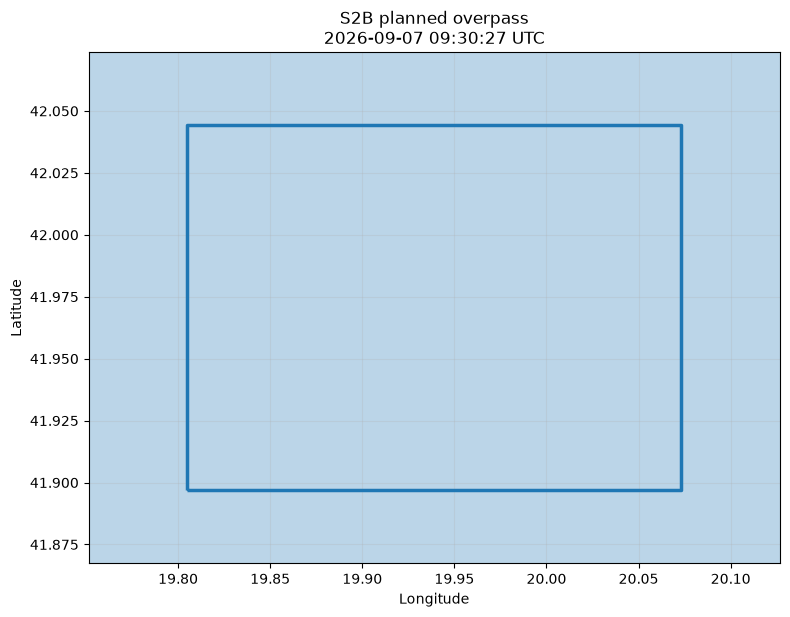

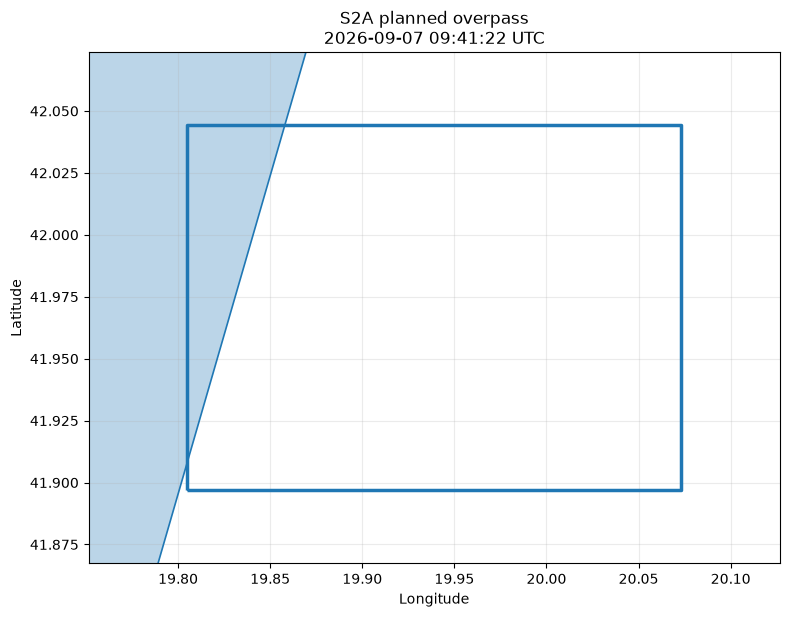

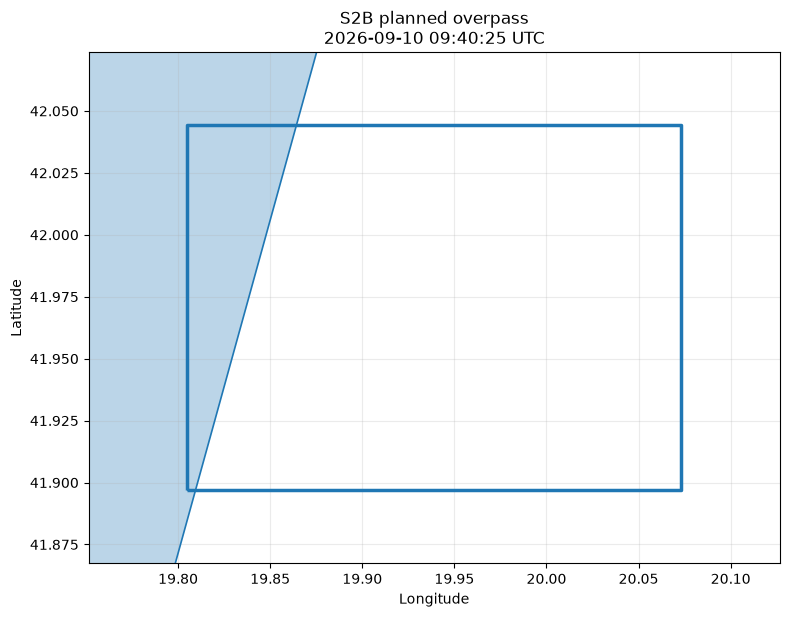

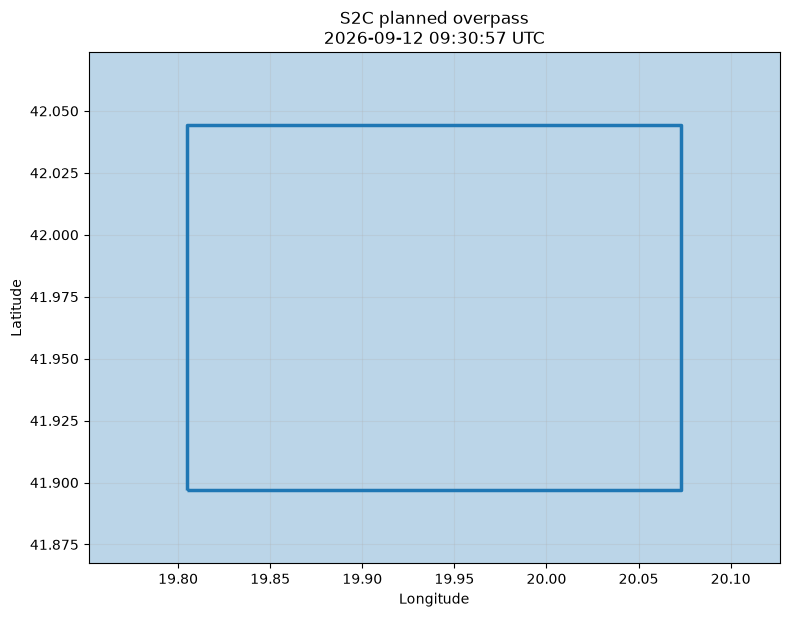

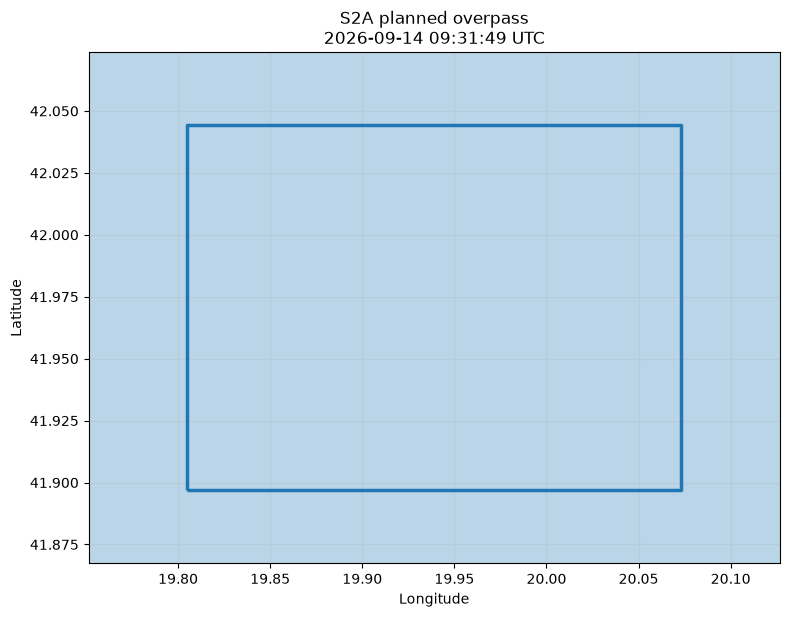

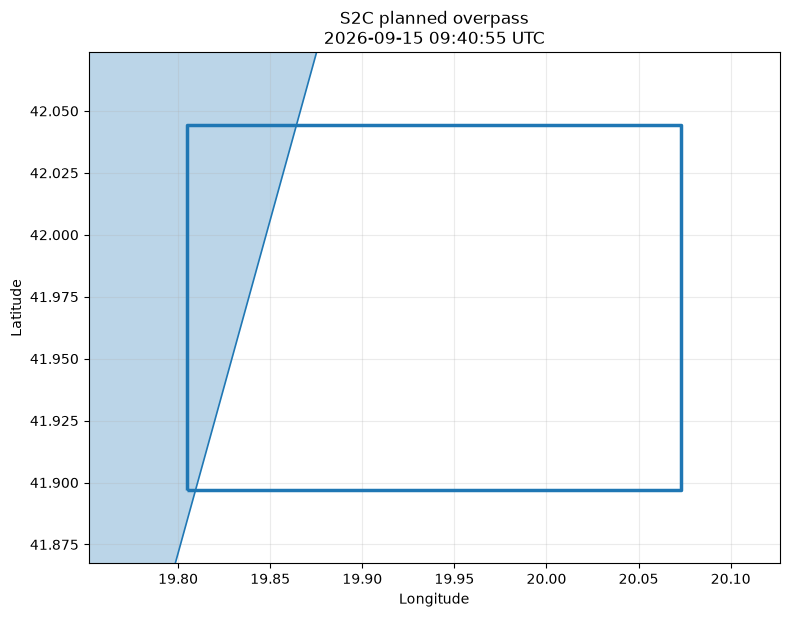

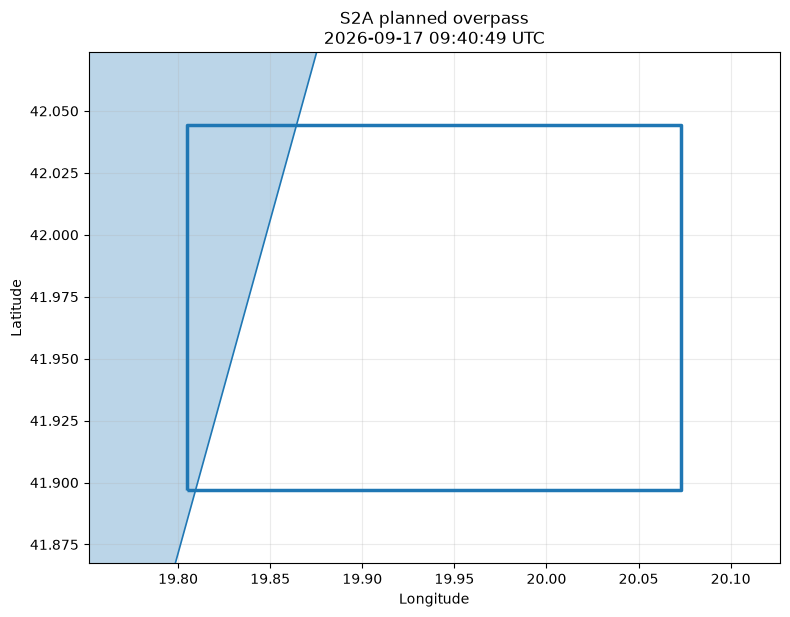

In [11]:
sentinel2_plotted, figures = plot_sentinel2_overpasses(
    aoi_path=AOI,
    days=DAYS,
    timezone_name=TIMEZONE,
)

## Search earlier than current time

In [16]:
# make the start time based on days before today
days_before_now=21

start_time = (
    datetime.now(timezone.utc)
    - timedelta(days=days_before_now)
)
print(start_time)

2026-08-11 13:03:59.241150+00:00


In [32]:
sentinel2_before = find_sentinel2_acquisitions(
    aoi_path=AOI,
    start=start_time,
    days=21,
)

sentinel2_before

AOI: mystorage/wildfire-aois/wildfire-albania-north-1.shp
Search window: 2026-08-11T13:03:59Z to 2026-09-01T13:03:59Z
Reading S2A plan: 2026-08-20T15:00:00Z → 2026-09-07T18:00:00Z
Reading S2A plan: 2026-08-06T15:00:00Z → 2026-08-24T18:00:00Z
Reading S2B plan: 2026-08-27T12:00:00Z → 2026-09-14T15:00:00Z
Reading S2B plan: 2026-08-13T12:00:00Z → 2026-08-31T15:00:00Z
Reading S2B plan: 2026-07-30T12:00:00Z → 2026-08-17T15:00:00Z
Reading S2C plan: 2026-08-20T12:00:00Z → 2026-09-07T15:00:00Z
Reading S2C plan: 2026-08-06T12:00:00Z → 2026-08-24T15:00:00Z
Found 12 acquisition(s).


,satellite,acquisition_id,start_utc,end_utc,plan_start_utc,plan_end_utc,plan_url
0,S2C,10116-2,2026-08-13T09:30:57Z,2026-08-13T09:52:14Z,2026-08-06T12:00:00Z,2026-08-24T15:00:00Z,https://sentinels.copernicus.eu/documents/d/se...
1,S2A,58220-2,2026-08-15T09:30:51Z,2026-08-15T09:52:08Z,2026-08-06T15:00:00Z,2026-08-24T18:00:00Z,https://sentinels.copernicus.eu/documents/d/se...
2,S2C,10159-2,2026-08-16T09:40:55Z,2026-08-16T10:01:51Z,2026-08-06T12:00:00Z,2026-08-24T15:00:00Z,https://sentinels.copernicus.eu/documents/d/se...
3,S2B,49354-2,2026-08-18T09:30:27Z,2026-08-18T09:51:44Z,2026-08-13T12:00:00Z,2026-08-31T15:00:00Z,https://sentinels.copernicus.eu/documents/d/se...
4,S2A,58263-2,2026-08-18T09:41:22Z,2026-08-18T09:52:51Z,2026-08-06T15:00:00Z,2026-08-24T18:00:00Z,https://sentinels.copernicus.eu/documents/d/se...
5,S2B,49397-2,2026-08-21T09:40:25Z,2026-08-21T10:01:21Z,2026-08-13T12:00:00Z,2026-08-31T15:00:00Z,https://sentinels.copernicus.eu/documents/d/se...
6,S2C,10259-2,2026-08-23T09:30:57Z,2026-08-23T09:52:14Z,2026-08-20T12:00:00Z,2026-09-07T15:00:00Z,https://sentinels.copernicus.eu/documents/d/se...
7,S2A,58363-2,2026-08-25T09:31:49Z,2026-08-25T09:42:53Z,2026-08-20T15:00:00Z,2026-09-07T18:00:00Z,https://sentinels.copernicus.eu/documents/d/se...
8,S2C,10302-2,2026-08-26T09:40:55Z,2026-08-26T10:01:51Z,2026-08-20T12:00:00Z,2026-09-07T15:00:00Z,https://sentinels.copernicus.eu/documents/d/se...
9,S2B,49497-2,2026-08-28T09:30:27Z,2026-08-28T09:51:44Z,2026-08-27T12:00:00Z,2026-09-14T15:00:00Z,https://sentinels.copernicus.eu/documents/d/se...


## Plot the previous days

AOI: mystorage/wildfire-aois/wildfire-albania-north-1.shp
Search window: 2026-08-11T13:03:59Z to 2026-09-01T13:03:59Z
Reading S2A plan: 2026-08-20T15:00:00Z → 2026-09-07T18:00:00Z
Reading S2A plan: 2026-08-06T15:00:00Z → 2026-08-24T18:00:00Z
Reading S2B plan: 2026-08-27T12:00:00Z → 2026-09-14T15:00:00Z
Reading S2B plan: 2026-08-13T12:00:00Z → 2026-08-31T15:00:00Z
Reading S2B plan: 2026-07-30T12:00:00Z → 2026-08-17T15:00:00Z
Reading S2C plan: 2026-08-20T12:00:00Z → 2026-09-07T15:00:00Z
Reading S2C plan: 2026-08-06T12:00:00Z → 2026-08-24T15:00:00Z
Found 12 acquisition(s).


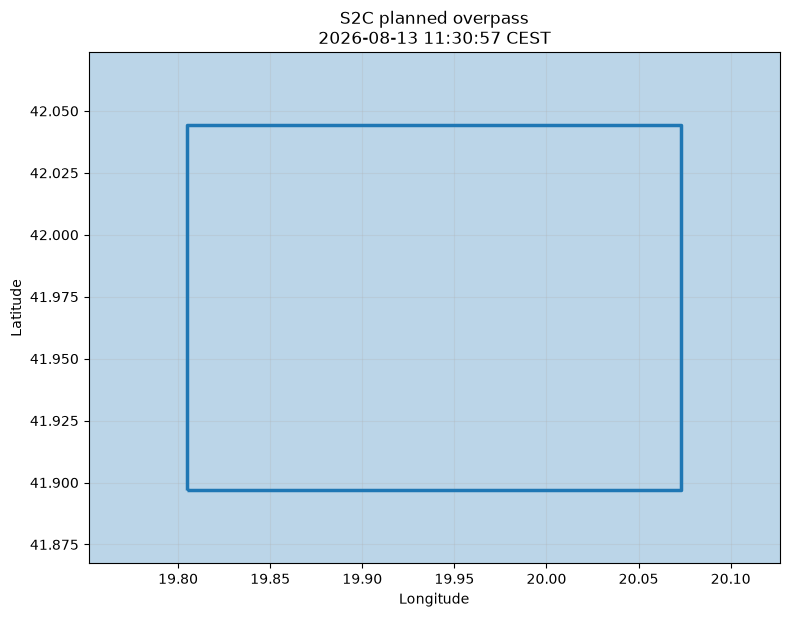

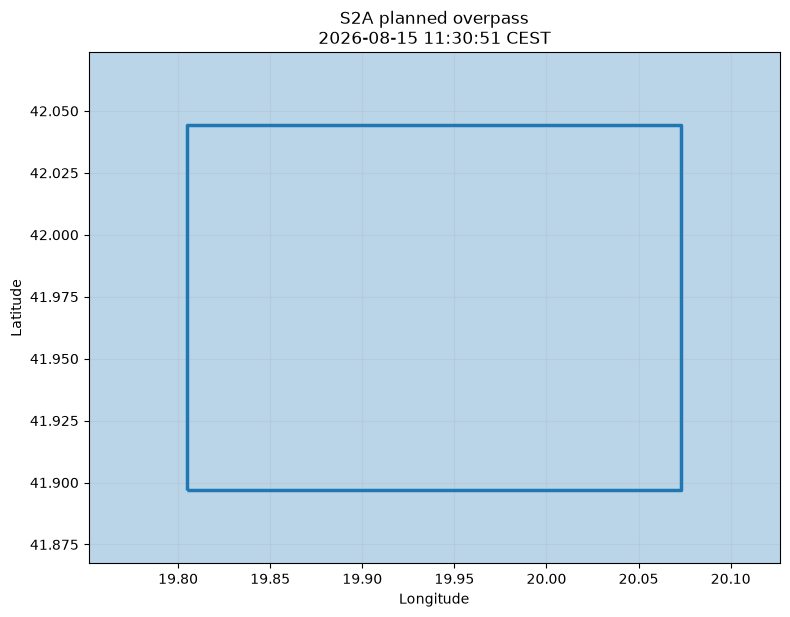

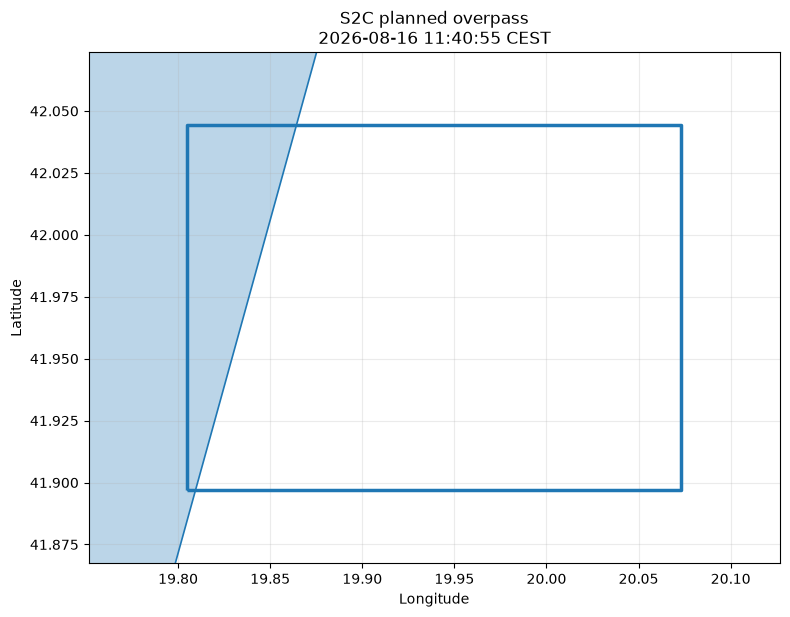

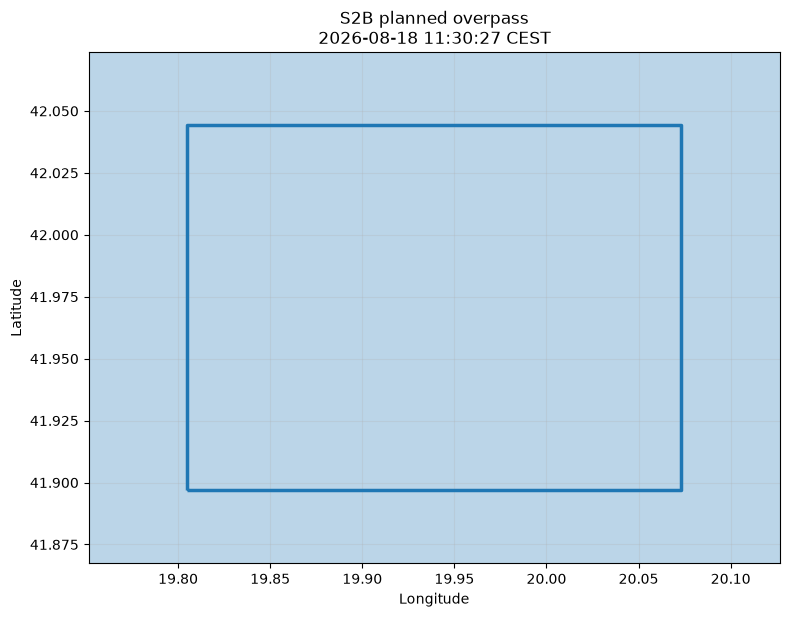

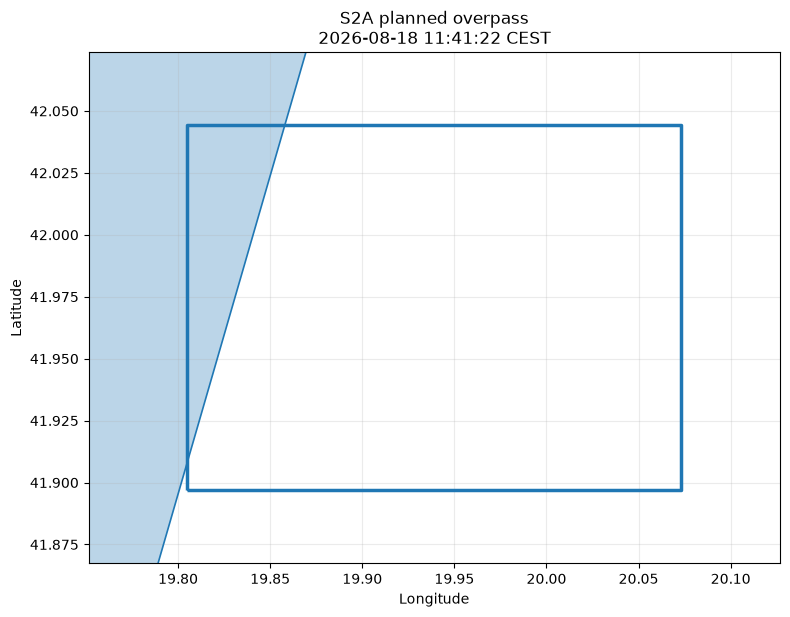

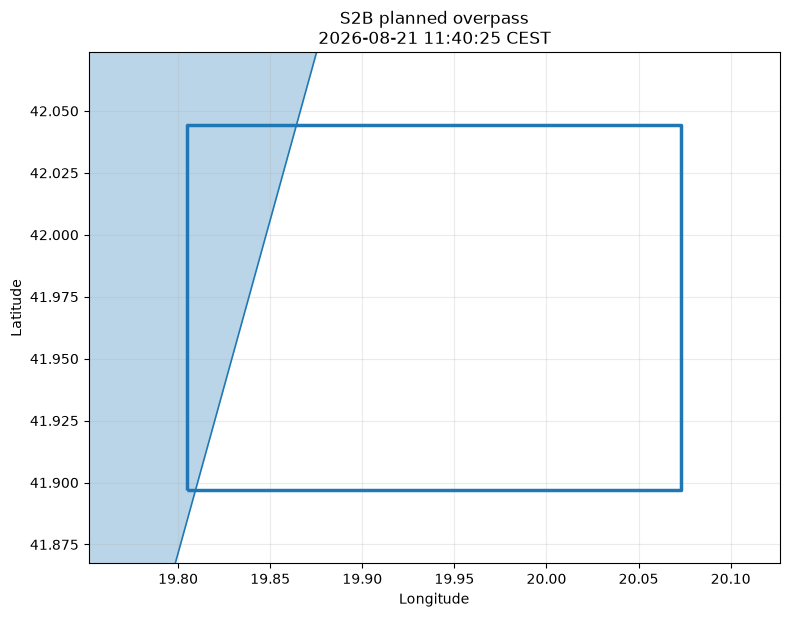

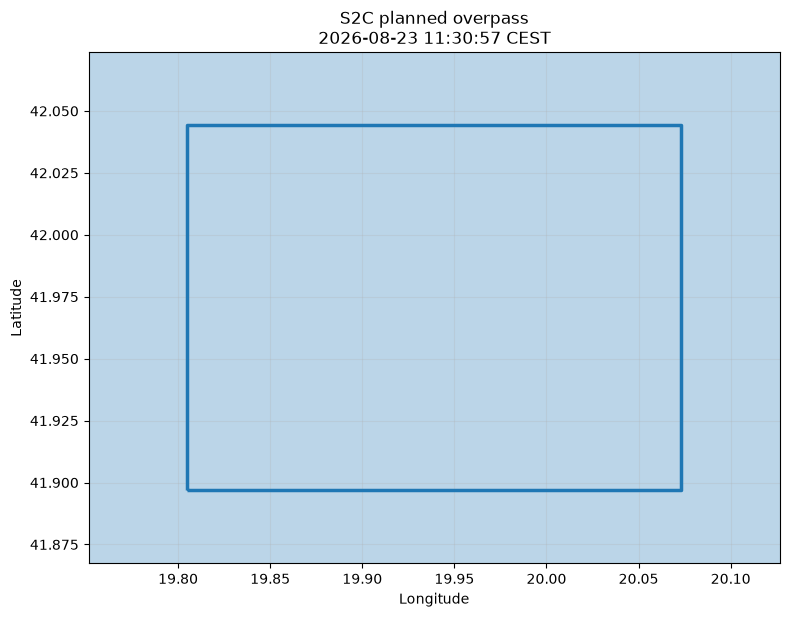

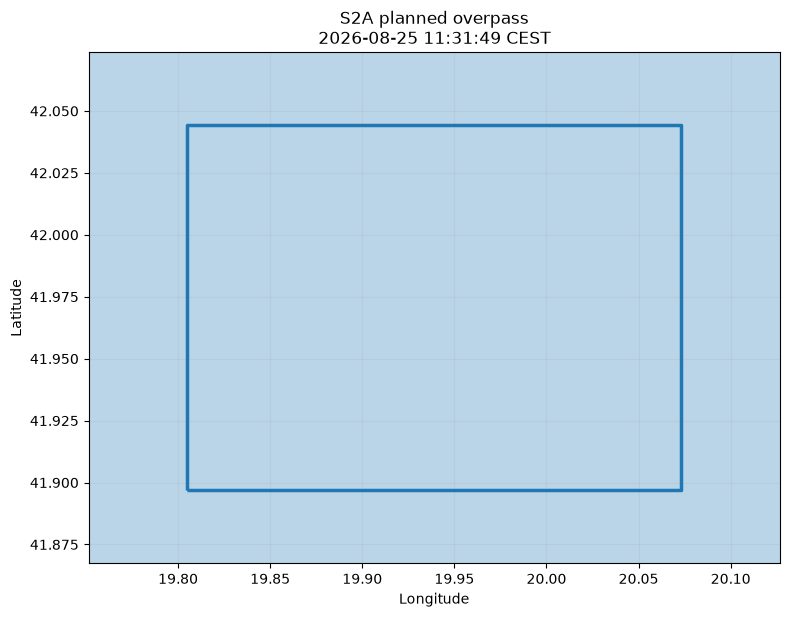

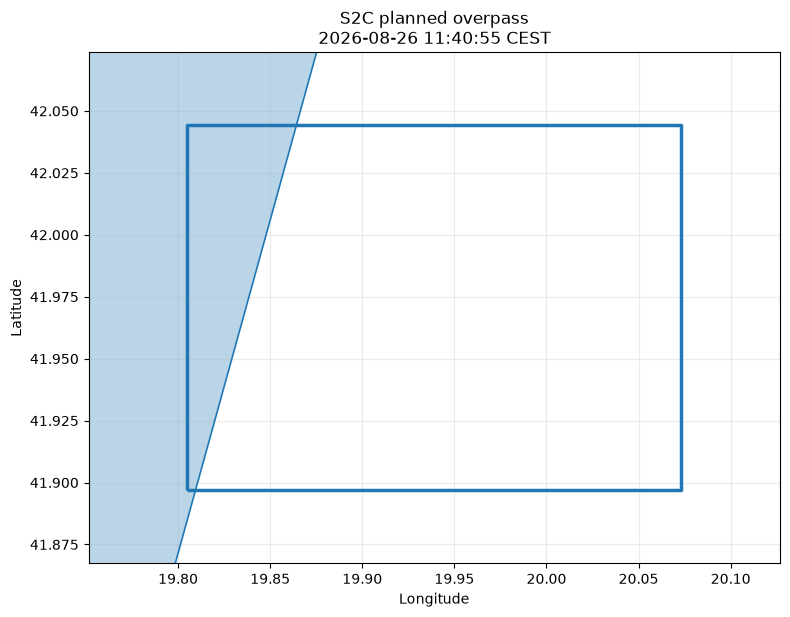

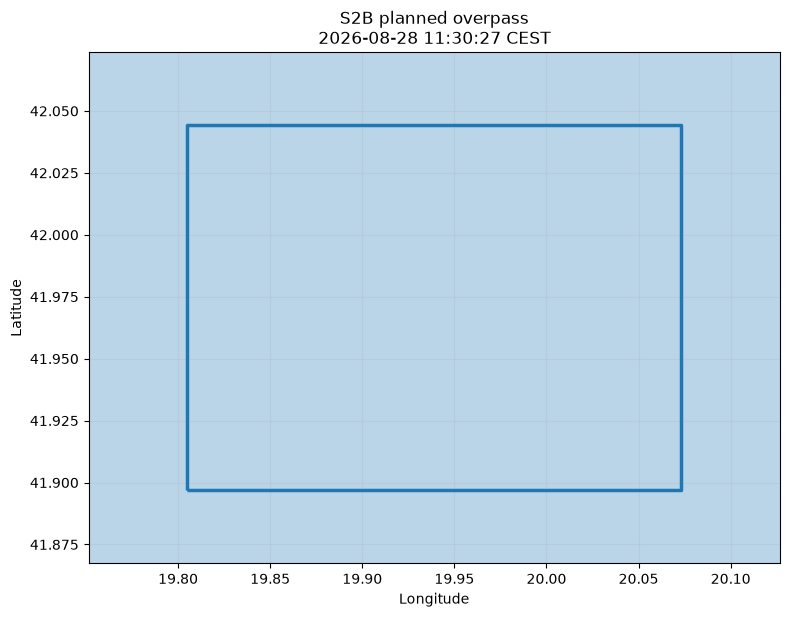

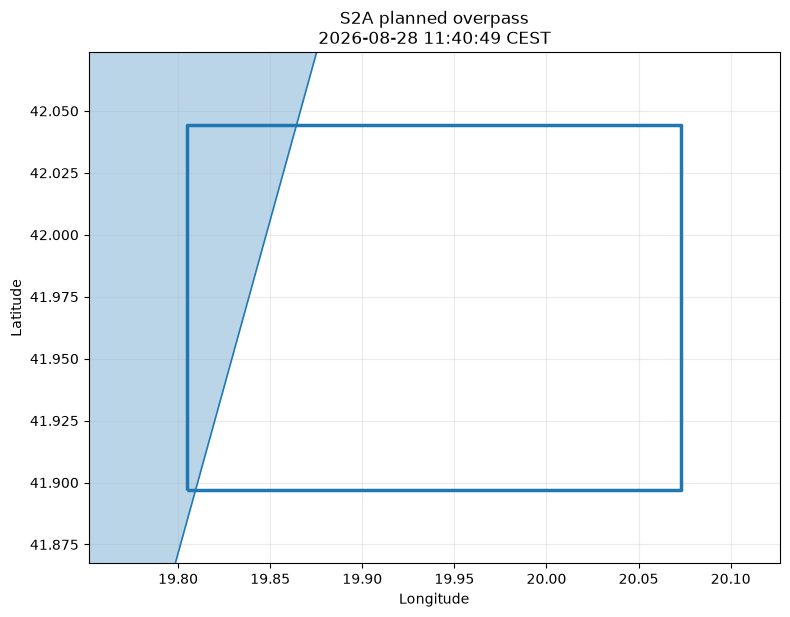

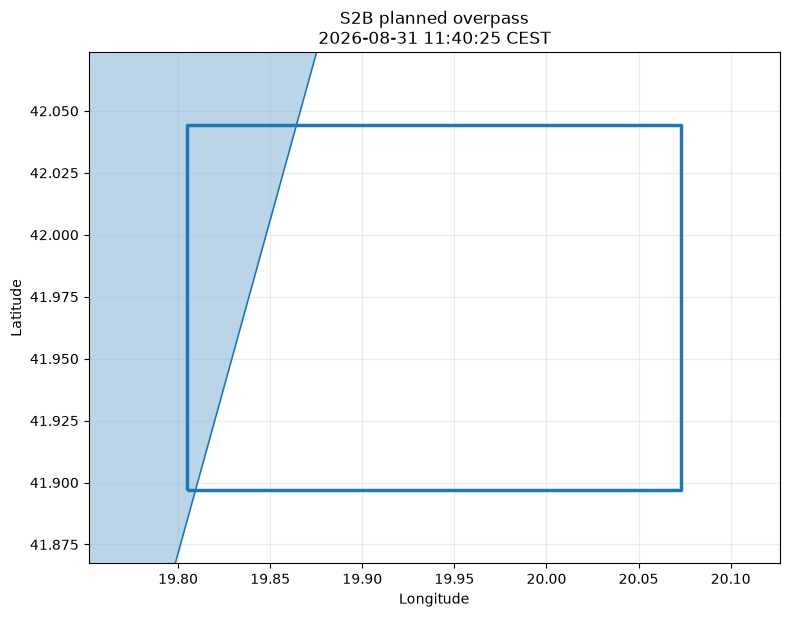

In [33]:
sentinel2_before_plotted, figures_last_week = (
    plot_sentinel2_overpasses(
        aoi_path=AOI,
        start=start_time,
        days=21,
        timezone_name=TIMEZONE,
    )
)

## Optional: save the current results to CSV

In [35]:
OUTPUT_CSV = Path(
    "mystorage/S2-aquisitions-ALB-WF1.csv"
)

# change the to the table you want to save e.g. (sentinel2_before_plotted, or sentinel2)
sentinel2_before_plotted.to_csv(
    OUTPUT_CSV,
    index=False,
)

print("Saved:", OUTPUT_CSV)

Saved: mystorage/S2-aquisitions-ALB-WF1.csv
